## MNIST

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np


# Load dataset
mnist=fetch_openml("mnist_784", version=1)

X=mnist.data 
y=mnist.target.astype(int)

X=X[:10000]
y=y[:10000]

# Normalize 
X=X/255.0

# Train / Test Split
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

## LOGISTIC REGRESSION

In [2]:
# Logistic Regression (Baseline)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log=log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.918


## KNN

In [3]:
# KNN 
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred_knn=knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.95


## SVM

In [4]:
# SVM 
from sklearn.svm import SVC

svm=SVC(kernel="rbf", probability=True) 
svm.fit(X_train, y_train)

y_pred_svm=svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.962


## Decision Tree 

In [5]:
# Decision Tree 
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(max_depth=20, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt=dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.826


## Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=100, 
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf=rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.955


## Hard and Soft Voting Classifier

In [7]:
from sklearn.ensemble import VotingClassifier

hard_voting=VotingClassifier(
    estimators=[
        ("lr", log_model),
        ("knn", knn),
        ("rf", rf),
        ("svm", svm)
    ],
    voting="hard"
)

hard_voting.fit(X_train, y_train)

y_pred_vote=hard_voting.predict(X_test)
print("Hard Voting Accuracy:", accuracy_score(y_test, y_pred_vote))


soft_voting=VotingClassifier(
    estimators=[
        ("lr", log_model),
        ("knn", knn),
        ("rf", rf),
        ("svm", svm)
    ],
    voting="soft"
)

soft_voting.fit(X_train, y_train)

y_pred_soft=soft_voting.predict(X_test)
print("Soft Voting Accuracy:", accuracy_score(y_test, y_pred_soft))

Hard Voting Accuracy: 0.9595
Soft Voting Accuracy: 0.9615


## Confusion Matrix


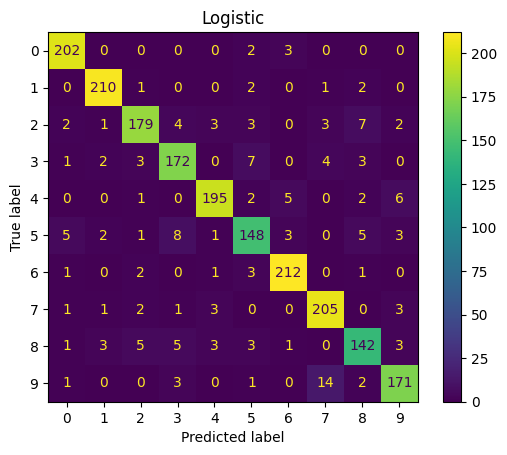

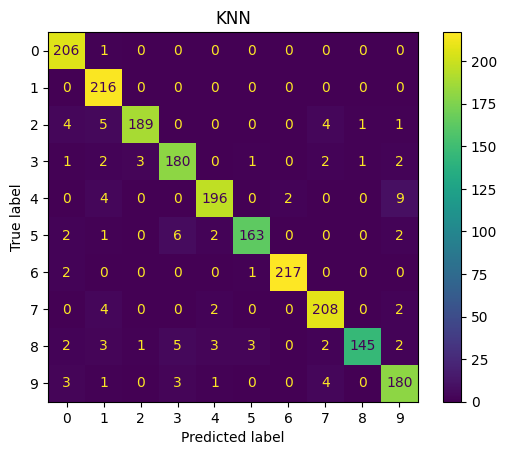

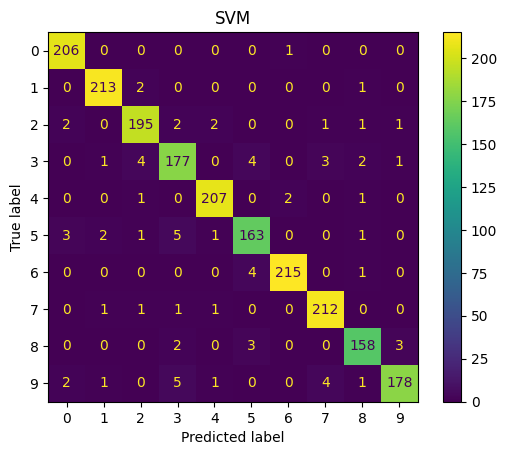

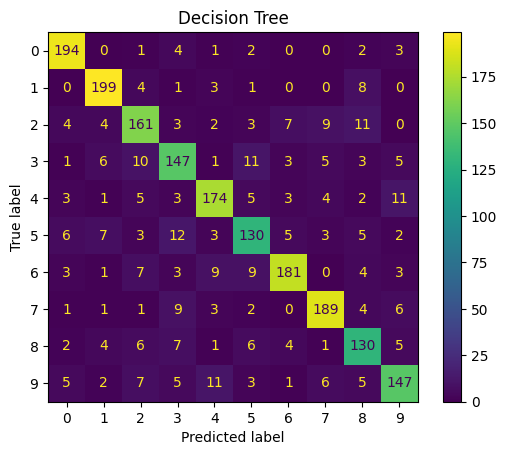

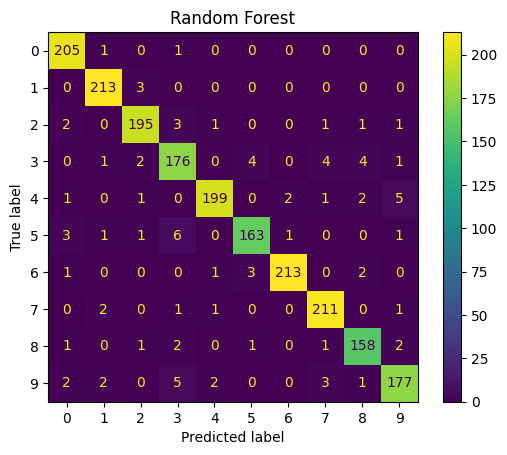

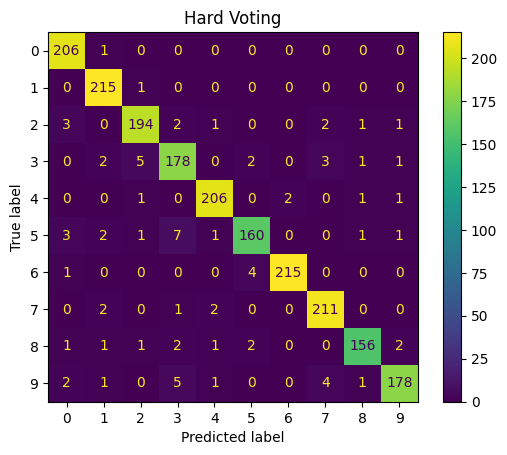

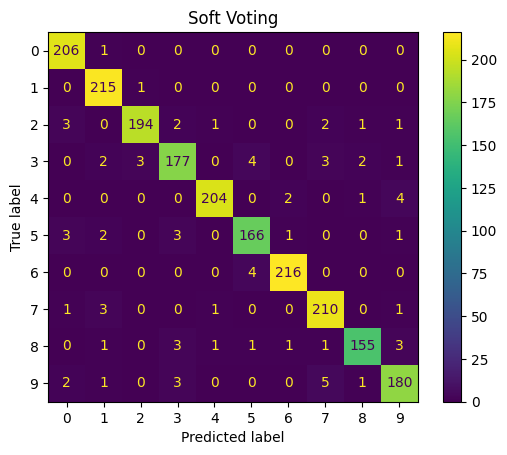

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models={
    "Logistic":log_model,
    "KNN":knn,
    "SVM":svm,
    "Decision Tree":dt,
    "Random Forest":rf,
    "Hard Voting": hard_voting, 
    "Soft Voting": soft_voting
}

for name, model in models.items():
    y_pred=model.predict(X_test)
    cm=confusion_matrix(y_test, y_pred)
    
    disp=ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

## Comparison Table

Logistic:0.9180
KNN:0.9500
SVM:0.9620
Decision Tree:0.8260
Random Forest:0.9550
Hard Voting:0.9595
Soft Voting:0.9615


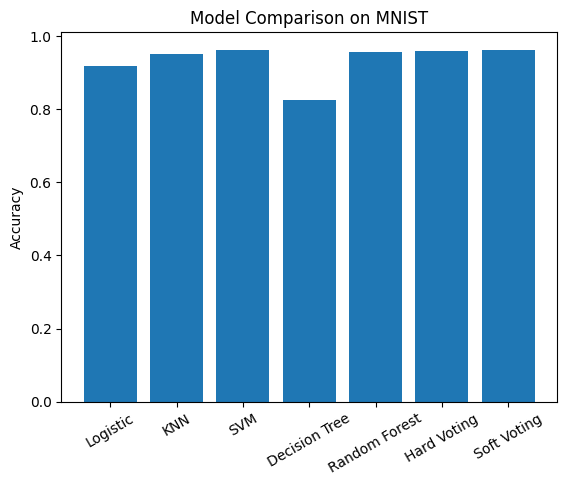

In [9]:
results={}

for name, model in models.items():
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test, y_pred)
    results[name]=acc

for name, acc in results.items():
    print(f"{name}:{acc:.4f}")
    
# Bar Chart
plt.bar(results.keys(), results.values()) #type:ignore
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Comparison on MNIST")
plt.show()

$$ \text{Variance Ratio} = \frac{\lambda_i}{\sum \lambda}